# 10 — 正式環境的持久化(Persistence)與部署(Deploy):兩件不同的事

**這份要學什麼**
- 把 `InMemorySaver` 換成 `SqliteSaver` / `PostgresSaver`，graph 程式碼完全不用改
- 部署的基本概念：一個編譯好的 graph 就是個 `Runnable`，包進你熟悉的 web framework 就能上線

> SqliteSaver 的部分不需要 API key、也不需要額外服務(用本機檔案就好)。

**這份先把兩個常被混在一起講的詞分開:**

- **Persistence(持久化)**:對話存檔要放在哪裡、能不能撐過程式重啟。
- **Deploy(部署)**:把整套系統包起來,讓「別人」可以連上來用(開一支 API、架一個服務)。

比喻成手機遊戲存檔:`06_langgraph_memory_checkpoint.ipynb` 用的 `InMemorySaver`,存檔只
留在這次開機的記憶體裡,程式一關,存檔就消失。這份要換成 `SqliteSaver` / `PostgresSaver`,
把存檔真的寫進硬碟或資料庫——像存檔存到雲端,換手機、重開機都還在。**好消息**:介面完全
一樣,只差在 `compile(checkpointer=...)` 傳進去的是哪個 saver 物件,圖本身的程式碼一行都
不用改。

```
InMemorySaver(06)                    SqliteSaver / PostgresSaver(這份)
┌───────────────────┐                ┌───────────────────┐
│ Python 行程的記憶體  │                │   硬碟檔案 / 資料庫  │
│      (RAM)         │                │(demo_persist.sqlite│
│                    │                │   / Postgres)      │
└─────────┬──────────┘                └─────────┬──────────┘
          │ 程式關掉                              │ 程式關掉
          ▼                                      ▼
      存檔消失                              存檔還在,下次重開
                                            程式讀得到同一份
```

部署(deploy)是另一件事,留到後面「部署概念」那段再談。

In [1]:
import os
import sys

sys.path.insert(0, ".")
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import END, START, MessagesState, StateGraph

from _graph_viz import show_graph


def echo(state: MessagesState) -> dict:
    return {"messages": [("ai", f"共 {len(state['messages']) + 1} 則")]}


def build_graph() -> StateGraph:
    builder = StateGraph(MessagesState)
    builder.add_node("echo", echo)
    builder.add_edge(START, "echo")
    builder.add_edge("echo", END)
    return builder


db_path = "demo_persist.sqlite"
if os.path.exists(db_path):
    os.remove(db_path)  # 這份 notebook 每次重跑都從乾淨狀態開始

## 用 `SqliteSaver` 取代 `InMemorySaver`

`SqliteSaver.from_conn_string(path)` 回傳一個 context manager,包住的 saver 物件直接丟給
`compile(checkpointer=saver)`——跟 `06` 用 `InMemorySaver()` 的方式一模一樣,只是這次資料
真的寫進 `path` 指到的 sqlite 檔案。

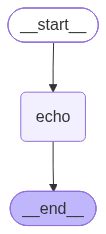

寫入後: ['第一句', '共 2 則']


In [2]:
config = {"configurable": {"thread_id": "persisted-session"}}

with SqliteSaver.from_conn_string(db_path) as saver:
    graph = build_graph().compile(checkpointer=saver)
    show_graph(graph)
    graph.invoke({"messages": [("human", "第一句")]}, config)
    print("寫入後:", [m.content for m in graph.get_state(config).values["messages"]])

## 驗證真的有「持久化」:模擬程式重啟

上面的 `with` 區塊結束後,`saver` 物件已經釋放了,等於「關掉程式」。現在重新開一個新的
`SqliteSaver`,指向同一個檔案、用同一個 `thread_id` 呼叫——如果狀態還在,就證明資料是真的
寫進磁碟,而不是留在剛剛那個已經結束的 Python 行程記憶體裡。

In [3]:
with SqliteSaver.from_conn_string(db_path) as saver:
    graph = build_graph().compile(checkpointer=saver)
    result = graph.invoke({"messages": [("human", "重啟後的第二句")]}, config)
    print("重啟後接續:", [m.content for m in result["messages"]])

os.remove(db_path)  # 清掉這份 notebook 產生的暫存檔

重啟後接續: ['第一句', '共 2 則', '重啟後的第二句', '共 4 則']


## `PostgresSaver`:同一套介面,換成多台機器共用的後端

這個 repo 沒有裝 `langgraph-checkpoint-postgres`(需要一個實際跑起來的 Postgres 服務,不
適合放進離線教材),但用法在概念上跟 `SqliteSaver` 對稱:

```python
from langgraph.checkpoint.postgres import PostgresSaver

with PostgresSaver.from_conn_string("postgresql://...") as saver:
    saver.setup()  # 第一次使用需要建表
    graph = build_graph().compile(checkpointer=saver)
```

**選型原則**:`SqliteSaver` 適合單機開發/demo,一個檔案搞定;`PostgresSaver` 適合正式環境
——當你的服務會開多個 instance 一起水平擴展、彼此要共用同一份對話狀態時,就需要一個大家
都連得到的資料庫,而不是各自機器上的一個檔案。

## 部署(Deploy)概念:先建立心智模型,細節之後再核對官方文件

> 這一段偏概念性,細節可能隨版本變動,正式導入前建議透過官方文件或 context7 核對當下版本
> 的確切用法,不要直接照抄。

一個編譯好的 `graph`(`CompiledStateGraph`)本質上是一個 `Runnable`,概念上最簡單的部署
方式,就是把它包進你熟悉的 web framework,讓它變成一支「請求進來、呼叫 graph、回傳結果」
的 API:

```python
# 概念示意,不是這個 repo 的一部分
from fastapi import FastAPI

app = FastAPI()
compiled_graph = build_graph().compile(checkpointer=saver)

@app.post("/chat/{thread_id}")
def chat(thread_id: str, message: str):
    config = {"configurable": {"thread_id": thread_id}}
    result = compiled_graph.invoke({"messages": [("human", message)]}, config)
    return {"reply": result["messages"][-1].content}
```

```
使用者發出請求(thread_id + 訊息)
        │
        ▼
   Web framework 收到(例如 FastAPI 的 /chat/{thread_id})
        │
        ▼
  compiled_graph.invoke(訊息, config={thread_id})
        │
        ▼
  checkpointer(Sqlite / Postgres)依 thread_id 讀寫這段對話的狀態
        │
        ▼
      把回覆送回使用者
```

概念上,LangGraph 官方也有提供類似 `langgraph-cli`(`langgraph dev` / `langgraph up`,設定
寫在 `langgraph.json`)這樣的工具,以及代管服務「LangGraph Platform」,幫忙處理掉
checkpointer 部署、水平擴展、內建的 human-in-the-loop / streaming API 等細節——**這部分
版本更新很快,這裡不細講確切指令跟行為**,正式要導入前務必自己核對官方文件當下的版本。

## 前十份小結

回顧到目前為止,你應該已經掌握:

1. **LCEL / Runnable**(01)—— LangChain 的基礎抽象,所有東西都能 `|` 串起來
2. **三層次 agent 對比**(02)—— `create_agent` 本質上就是編譯出一個 `StateGraph`
3. **State / Node / Edge**(03)—— reducer 決定「覆蓋」還是「合併」
4. **條件邊 / `Command` / `Send`**(04)—— 圖如何表達分支、迴圈、fan-out
5. **`bind_tools` / `ToolNode` / `tools_condition`**(05)—— 工具呼叫迴圈的每個環節,
   以及錯誤處理的陷阱
6. **Checkpointer / `thread_id`**(06)—— 短期記憶:同一個對話串內狀態怎麼持久化
7. **`interrupt()` / `Command(resume=...)`**(07)—— human-in-the-loop 的標準模式
8. **`stream_mode`**(08)—— `values` / `updates` / `messages` / `debug` 各自的用途
9. **Supervisor pattern + subgraph**(09)—— 多 agent 協作的骨架
10. **`SqliteSaver` / `PostgresSaver` + 部署概念**(這份)

### 接下來
- **下一份 `11_langgraph_long_term_memory.ipynb`**:`06` 教的 checkpointer 只在單一
  `thread_id` 範圍內有效;如果要跨對話記住使用者偏好,要看 `BaseStore`——這是獨立於
  checkpointer 的另一個機制,緊接在這份持久化主題後面剛好連貫
- **`12_langsmith_observability.ipynb`**:追蹤、除錯、評估 agent 行為的工具 LangSmith,
  概念上跟這系列的 `stream_mode="debug"` 是互補關係,會更深入介紹
- **真的接上 API key**:把每份 notebook 裡「如果你有 API key」的 cell 打開,比較
  `scripted_model` 跟真模型在同一個流程下的行為差異